# Email Domains Visualization

In [113]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [114]:
# Check data directory
!ls "../assignments/data/"

python(14910) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


people-1000.csv


In [115]:
# Set data directory and filename
datadir = "../assignments/data/"
filename="people-1000.csv"

In [116]:
# Read the CSV file into a DataFrame
df = pd.read_csv(datadir+filename)

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Index          1000 non-null   int64 
 1   User Id        1000 non-null   object
 2   First Name     1000 non-null   object
 3   Last Name      1000 non-null   object
 4   Sex            1000 non-null   object
 5   Email          1000 non-null   object
 6   Phone          1000 non-null   object
 7   Date of birth  1000 non-null   object
 8   Job Title      1000 non-null   object
dtypes: int64(1), object(8)
memory usage: 70.4+ KB


In [118]:
# Show the first three rows of the DataFrame
df.head(3)

,Index,User Id,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
0,1,8717bbf45cCDbEe,Shelia,Mahoney,Male,pwarner@example.org,857.139.8239,2014-01-27,Probation officer
1,2,3d5AD30A4cD38ed,Jo,Rivers,Female,fergusonkatherine@example.net,+1-950-759-8687,1931-07-26,Dancer
2,3,810Ce0F276Badec,Sheryl,Lowery,Female,fhoward@example.org,(599)782-0605,2013-11-25,Copy


## Extracting email domain 
To extract the domain, I used `str.split()` method demonstrated as part of the lecture 3 tutorial. For more information on how it works, I referred to [W3schools](https://www.w3schools.com/python/ref_string_split.asp).

In [119]:
# Extract email domains and add as a new column 'Domain'
df['Domain'] = df['Email'].str.split('@').str[1]
df.head(3)

,Index,User Id,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Domain
0,1,8717bbf45cCDbEe,Shelia,Mahoney,Male,pwarner@example.org,857.139.8239,2014-01-27,Probation officer,example.org
1,2,3d5AD30A4cD38ed,Jo,Rivers,Female,fergusonkatherine@example.net,+1-950-759-8687,1931-07-26,Dancer,example.net
2,3,810Ce0F276Badec,Sheryl,Lowery,Female,fhoward@example.org,(599)782-0605,2013-11-25,Copy,example.org


## Prepare data for pie chart

To prepare data for visualization, such as counts of domain occurences and extracting unique labels, I referred to Pandas documentation: 
- [DataFrame.value_counts()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html)
- [pandas.unique()](https://pandas.pydata.org/docs/reference/api/pandas.unique.html)


In [120]:
# Count occurrences of each domain for pie chart
domain_counts = df['Domain'].value_counts()

In [121]:
# Extract unique domains for labels
chart_labels = df['Domain'].unique()

## Create a Pie Chart for Email Domains

The pie chart was created based on a code exemple demonstrated as part of the official [matplotlib](https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_and_donut_labels.html#sphx-glr-gallery-pie-and-polar-charts-pie-and-donut-labels-py) documentation. Necessary modifications were performed in order to adapt the code to the assignment task.

Further learning of `autopct()` was based on the [Python Matplotlib - Pie Chart autopct()](https://pythonexamples.org/python-matplotlib-pie-chart-autopct/#google_vignette) tutorial.

Additionally, percentages conversion within a fuction was explored through [ChatGPT](https://chatgpt.com/c/68ffa0b0-2c60-832e-9c35-02df0b15b6b2).

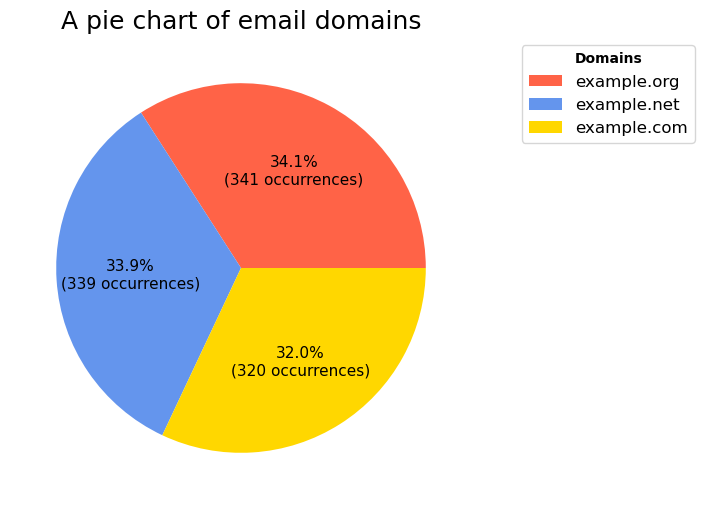

In [ ]:
# Create pie chart
fig, ax = plt.subplots(figsize=(6, 6))

# Create a function to display percentage and absolute values on pie chart
# Pass the percentage and the count of all values to the function
def format_labels(pct, all_vals):
    # convert pct to absolute value
    absolute = int(round(pct/100.0 * sum(all_vals)))
    # return formatted label containing both percentage and absolute value
    return f"{pct:.1f}%\n({absolute} occurrences)"

# Create pie chart: pass domain counts and use autopct to display percentages + counts
wedges, texts, autotexts = ax.pie(domain_counts, 
                                autopct=lambda pct: format_labels(pct, domain_counts),
                                # Chart lables colors
                                textprops=dict(color="black", size=11),
                                # Wedges colors
                                colors=[
                                    # matplotlib named colors 
                                    'tomato', 'cornflowerblue', 'gold']
                                )
    
# Create legend
legend = ax.legend(wedges, chart_labels,
          title="Domains",
          loc="upper right",
          bbox_to_anchor=(1, 0, 0.5, 1),
          prop={'size': 12}  # Increase legend text size
          )
# Make legend title bold
ax.legend_.get_title().set_fontweight('bold')

# Setting title
ax.set_title("A pie chart of email domains", size=18)

plt.show()

## End